# 02 - Phân tích đơn biến (Univariate)
**Phụ trách: Nguyễn Thành Đại (TV2)**.

In [1]:
import sys; sys.path.append('../src')
from eda_utils import *
train, test = load()
print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [2]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
cont = CONTINUOUS; disc = DISCRETE
cats = [c for c in feat if GROUP_OF[c] in ('nominal','ordinal')]

## 1. Biến mục tiêu SalePrice

count      1460.00
mean     180921.20
std       79442.50
min       34900.00
25%      129975.00
50%      163000.00
75%      214000.00
max      755000.00
skew          1.88
kurt          6.54
Name: SalePrice, dtype: float64
Sau log1p: skew = 0.121 , kurt = 0.81


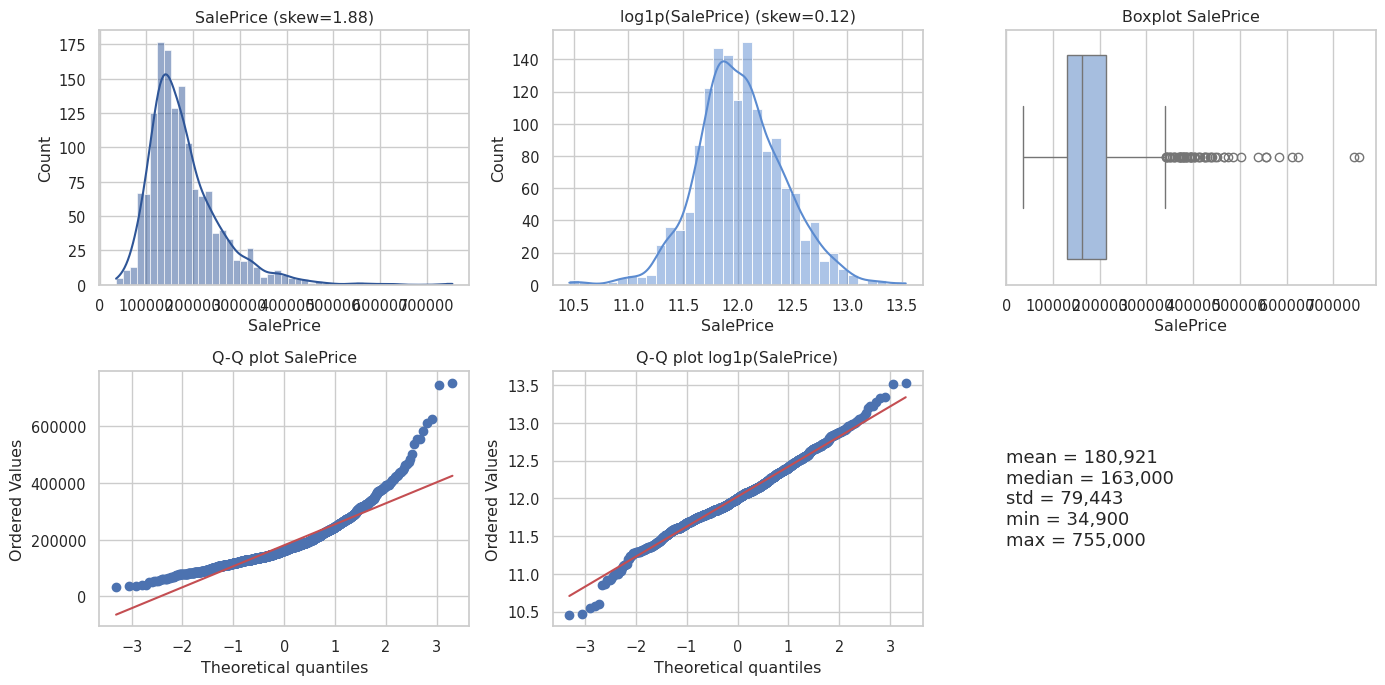

In [3]:
y = train.SalePrice
st = y.describe(); st['skew'] = y.skew(); st['kurt'] = y.kurt()
print(st.round(2)); print('Sau log1p: skew =', round(np.log1p(y).skew(), 3), ', kurt =', round(np.log1p(y).kurt(), 3))
from scipy import stats
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
sns.histplot(y, kde=True, ax=ax[0,0], color='#2E5597'); ax[0,0].set_title(f'SalePrice (skew={y.skew():.2f})')
sns.histplot(np.log1p(y), kde=True, ax=ax[0,1], color='#5B8BD0'); ax[0,1].set_title(f'log1p(SalePrice) (skew={np.log1p(y).skew():.2f})')
sns.boxplot(x=y, ax=ax[0,2], color='#9DBCE8'); ax[0,2].set_title('Boxplot SalePrice')
stats.probplot(y, plot=ax[1,0]); ax[1,0].set_title('Q-Q plot SalePrice')
stats.probplot(np.log1p(y), plot=ax[1,1]); ax[1,1].set_title('Q-Q plot log1p(SalePrice)')
ax[1,2].axis('off'); ax[1,2].text(0, .5, f"mean = {y.mean():,.0f}\nmedian = {y.median():,.0f}\nstd = {y.std():,.0f}\nmin = {y.min():,.0f}\nmax = {y.max():,.0f}", fontsize=13, va='center')
save_fig('02_saleprice')

## 2. Biến liên tục

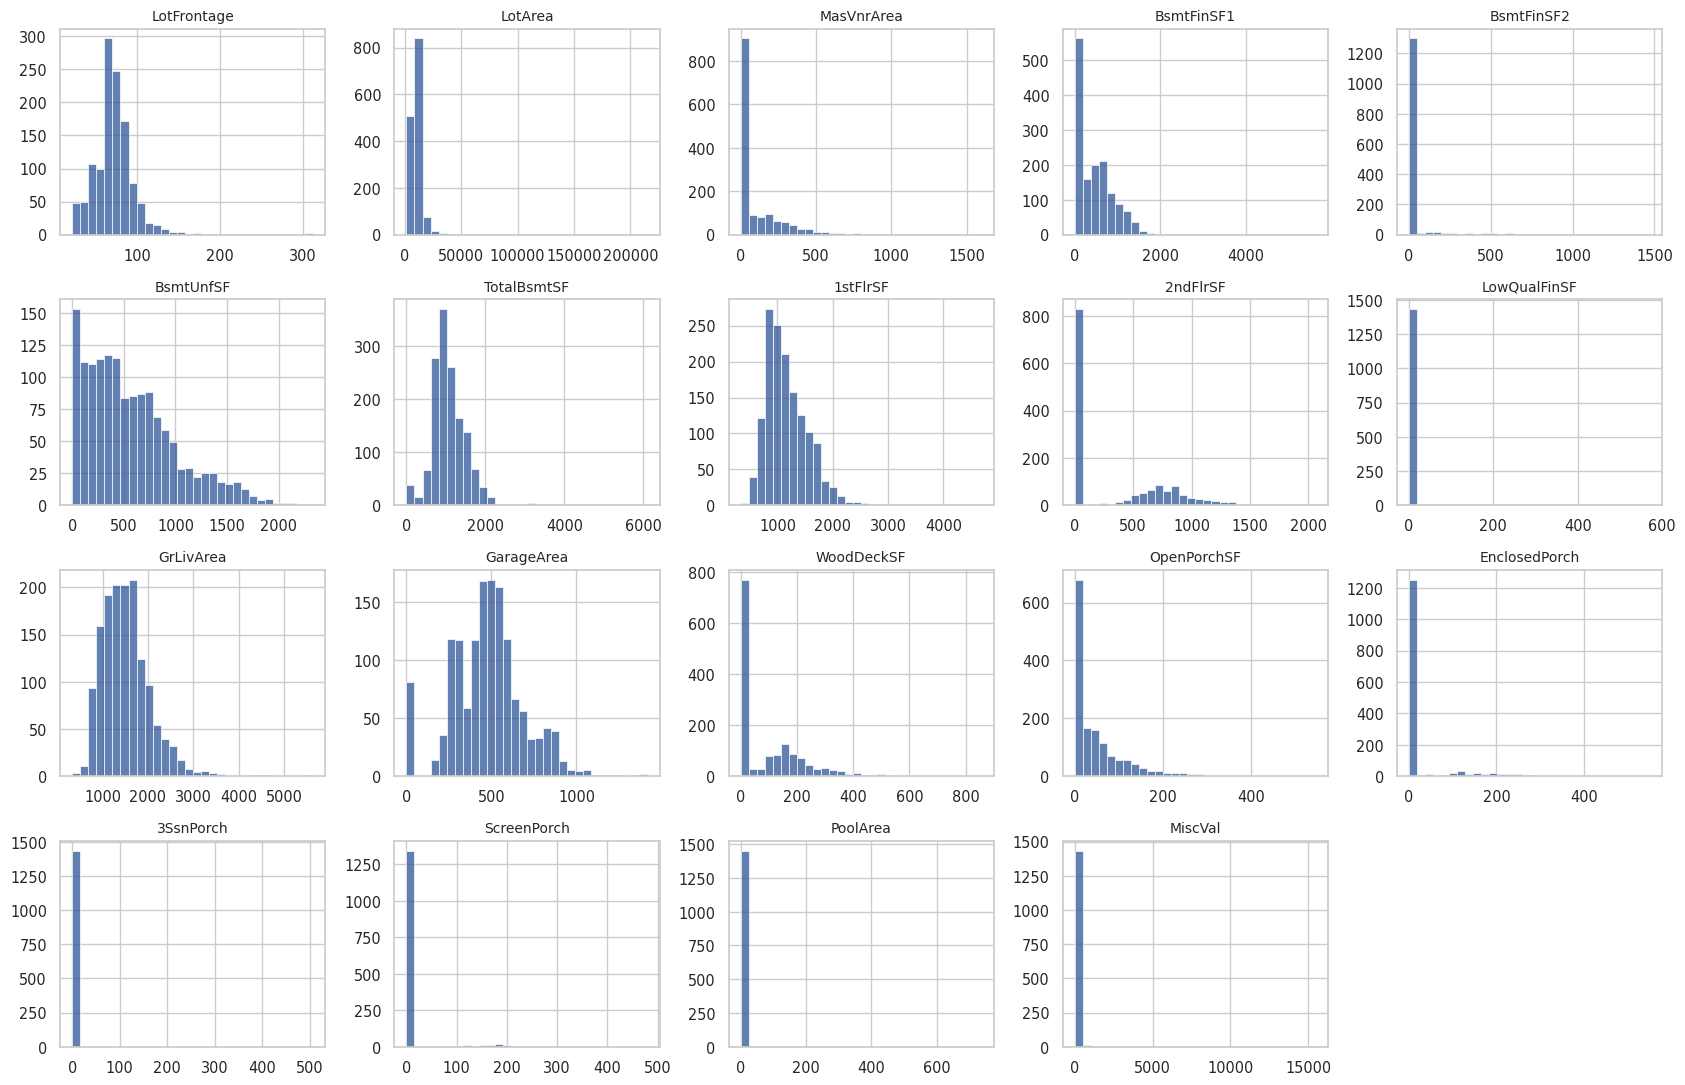

Tỉ lệ giá trị 0:
PoolArea         99.5
3SsnPorch        98.4
LowQualFinSF     98.2
MiscVal          96.4
ScreenPorch      92.1
BsmtFinSF2       88.6
EnclosedPorch    85.8
MasVnrArea       59.0
2ndFlrSF         56.8
WoodDeckSF       52.1
OpenPorchSF      44.9
BsmtFinSF1       32.0


In [4]:
fig, axes = plt.subplots(4, 5, figsize=(17, 11))
for a, c in zip(axes.ravel(), cont):
    sns.histplot(train[c].dropna(), bins=30, ax=a, color='#2E5597'); a.set_title(c, fontsize=10); a.set_xlabel(''); a.set_ylabel('')
axes.ravel()[-1].axis('off')
save_fig('02_lienTuc_hist')
zero = (train[cont] == 0).mean().sort_values(ascending=False)
sk = train[cont + disc].skew().sort_values(ascending=False)
print('Tỉ lệ giá trị 0:'); print((zero[zero > 0.3] * 100).round(1).to_string())

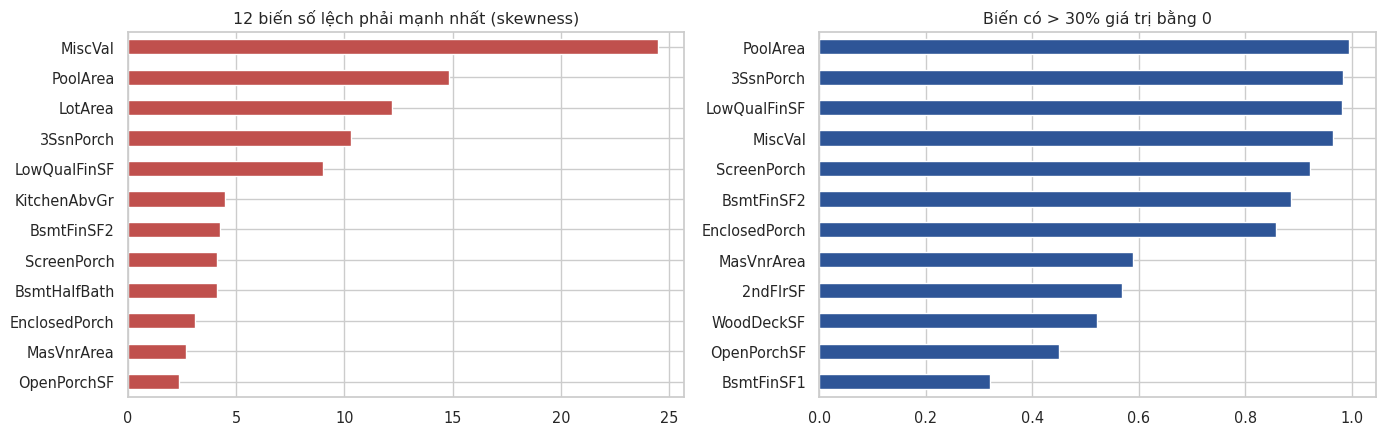

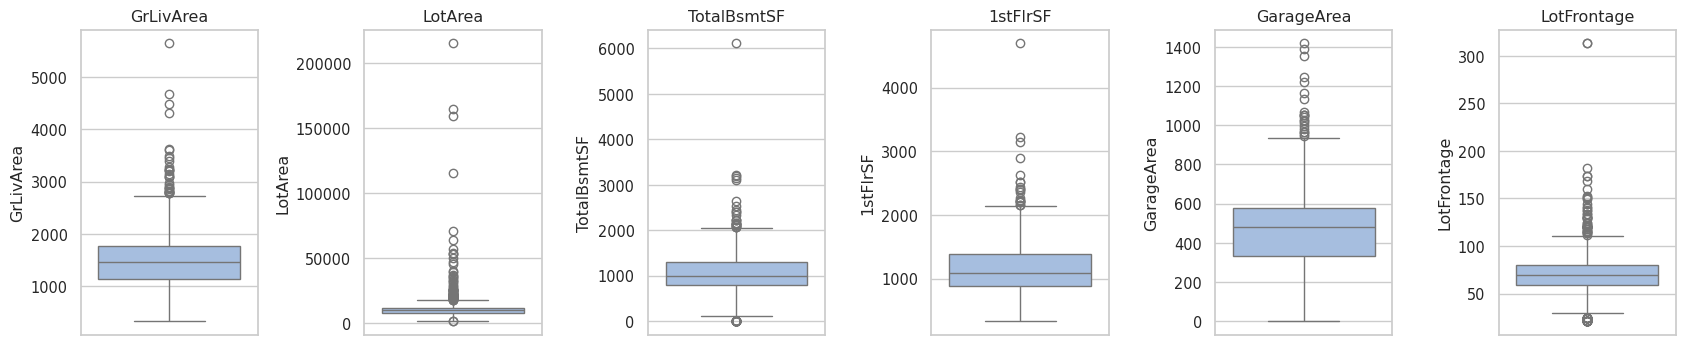

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sk.head(12).sort_values().plot.barh(ax=ax[0], color='#C0504D'); ax[0].set_title('12 biến số lệch phải mạnh nhất (skewness)')
zero[zero > 0.3].sort_values().plot.barh(ax=ax[1], color='#2E5597'); ax[1].set_title('Biến có > 30% giá trị bằng 0')
save_fig('02_skew_zero')
key = ['GrLivArea','LotArea','TotalBsmtSF','1stFlrSF','GarageArea','LotFrontage']
fig, axes = plt.subplots(1, 6, figsize=(17, 3.6))
for a, c in zip(axes, key): sns.boxplot(y=train[c], ax=a, color='#9DBCE8'); a.set_title(c)
save_fig('02_box_key')

## 3. Biến rời rạc

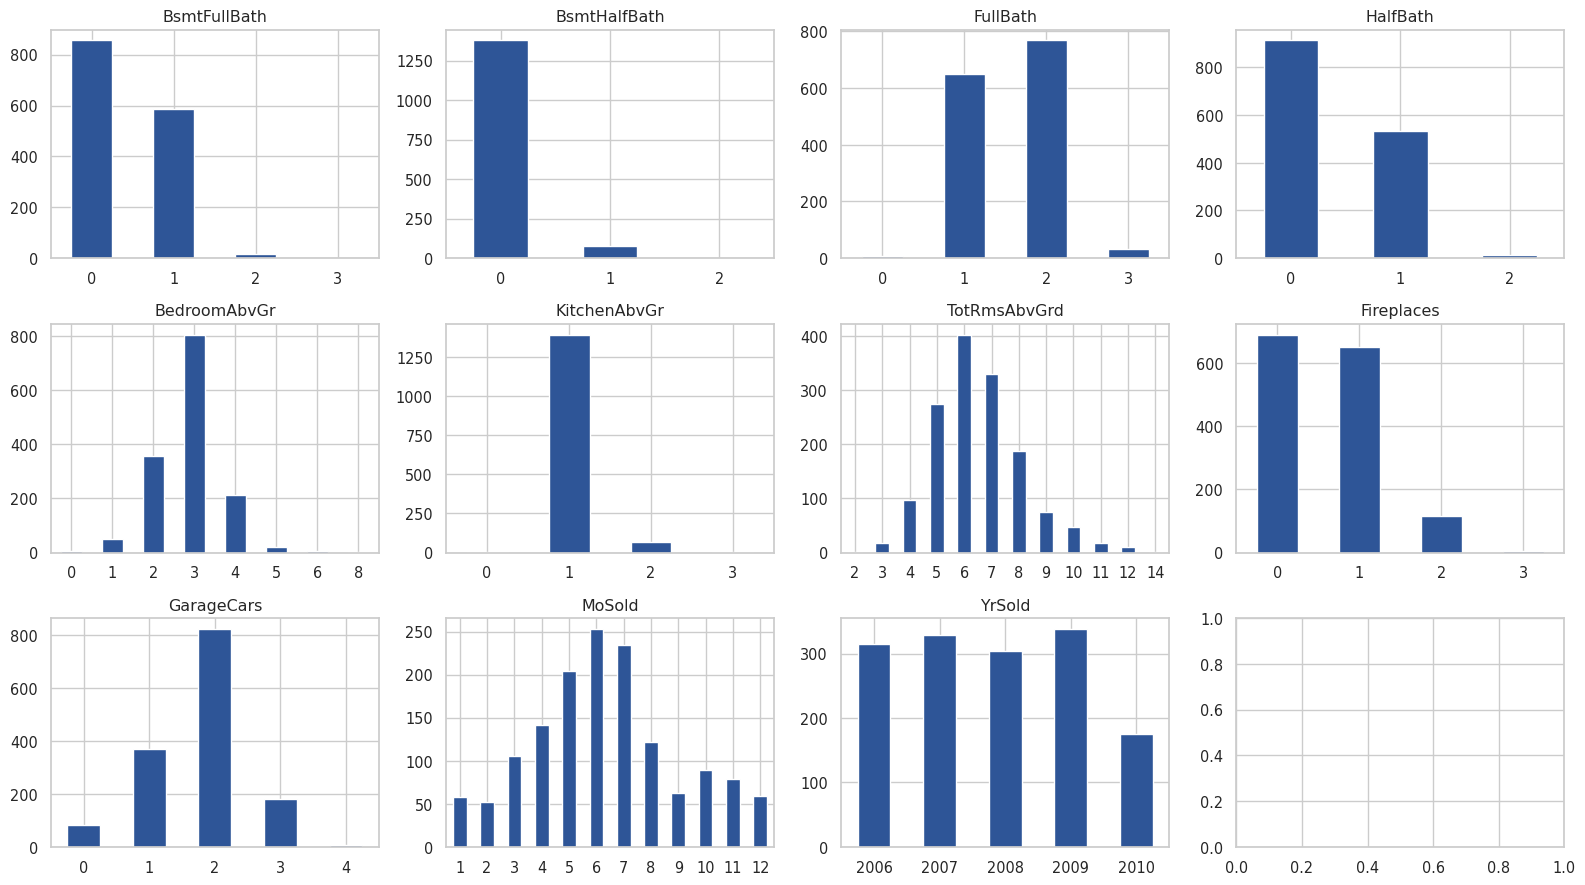

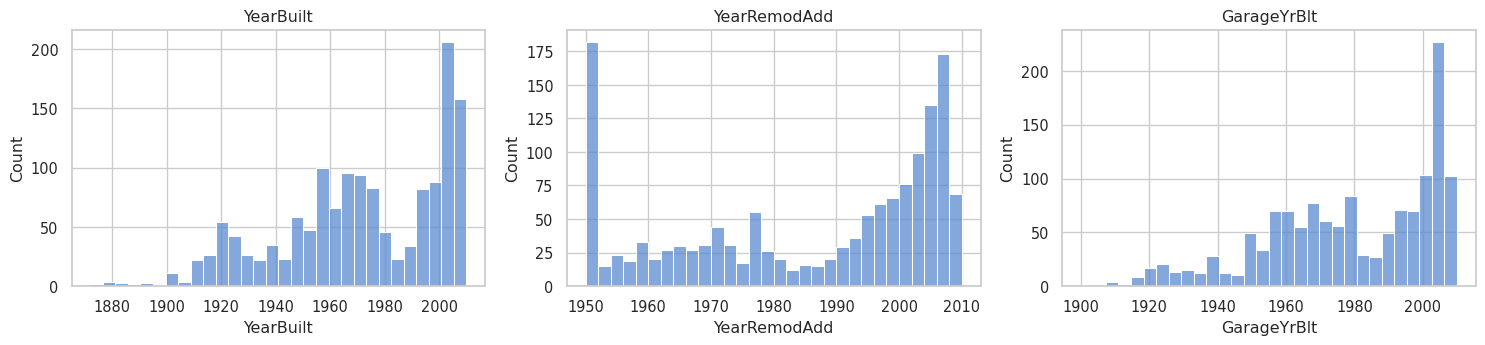

In [6]:
dc = [c for c in disc if c not in ('YearBuilt','YearRemodAdd','GarageYrBlt')]
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for a, c in zip(axes.ravel(), dc):
    train[c].value_counts().sort_index().plot.bar(ax=a, color='#2E5597', rot=0); a.set_title(c); a.set_xlabel('')
save_fig('02_rời_rạc')
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for a, c in zip(axes, ['YearBuilt','YearRemodAdd','GarageYrBlt']): sns.histplot(train[c].dropna(), bins=30, ax=a, color='#5B8BD0'); a.set_title(c)
save_fig('02_nam')

## 4. Biến phân loại (nominal + ordinal)

Biến gần như hằng số (>95% một giá trị):


,levels,top_share,top
Utilities,2,0.999,AllPub
Street,2,0.996,Pave
PoolQC,4,0.995,NaN
Condition2,8,0.990,Norm
RoofMatl,8,0.982,CompShg
Heating,6,0.978,GasA
MiscFeature,5,0.963,NaN


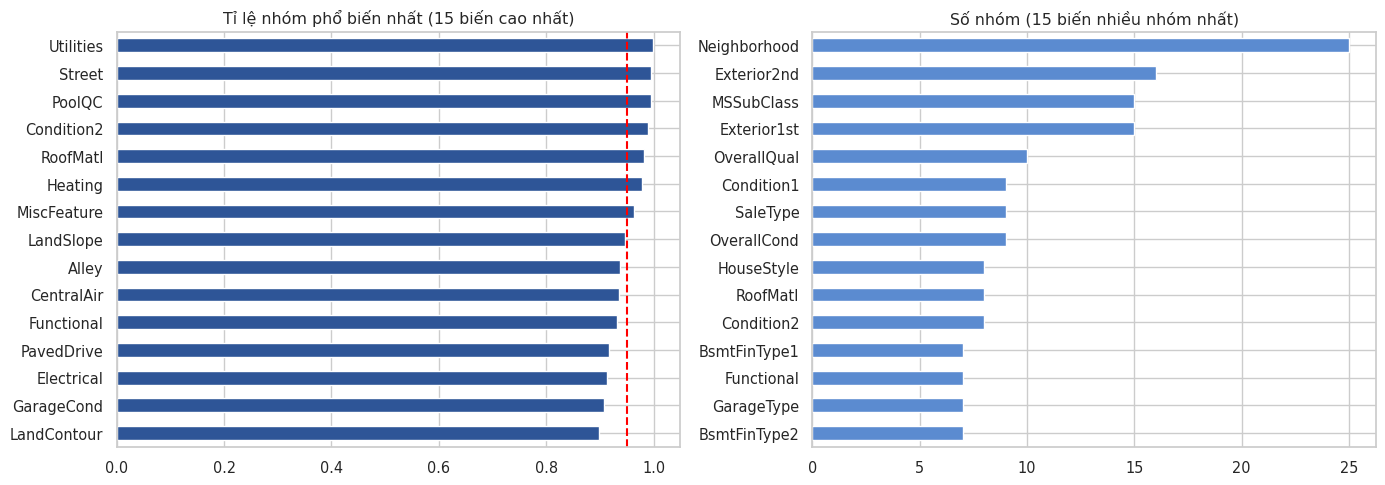

In [7]:
freq = pd.DataFrame({'levels': [train[c].nunique(dropna=False) for c in cats],
  'top_share': [train[c].value_counts(normalize=True, dropna=False).iloc[0] for c in cats],
  'top': [train[c].value_counts(dropna=False).index[0] for c in cats]}, index=cats)
near = freq[freq.top_share > 0.95].sort_values('top_share', ascending=False)
print('Biến gần như hằng số (>95% một giá trị):'); display(near.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
freq.top_share.sort_values(ascending=False).head(15).sort_values().plot.barh(ax=ax[0], color='#2E5597'); ax[0].axvline(.95, color='red', ls='--')
ax[0].set_title('Tỉ lệ nhóm phổ biến nhất (15 biến cao nhất)')
freq.levels.sort_values(ascending=False).head(15).sort_values().plot.barh(ax=ax[1], color='#5B8BD0'); ax[1].set_title('Số nhóm (15 biến nhiều nhóm nhất)')
save_fig('02_cat_overview')

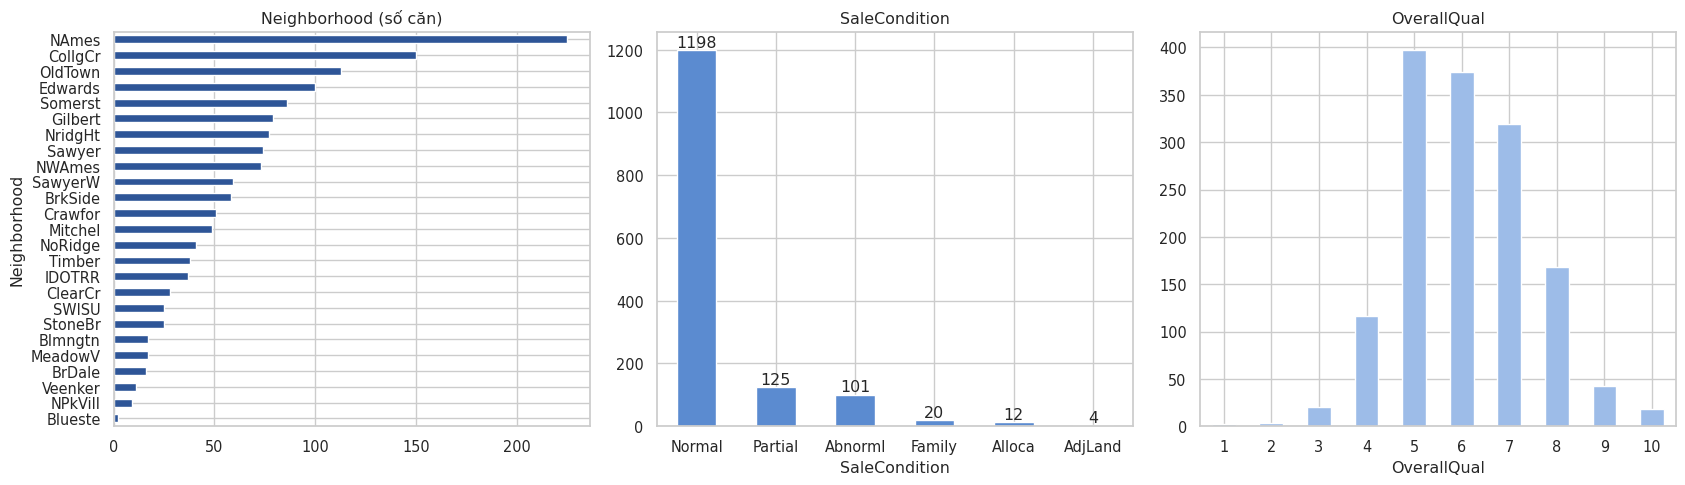

Số nhóm hiếm (<10 căn) lớn nhất: [('Condition2', 7), ('RoofMatl', 6), ('SaleType', 6), ('Exterior1st', 5), ('Exterior2nd', 5), ('Heating', 4), ('Condition1', 3), ('GarageCond', 3)]


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
train.Neighborhood.value_counts().sort_values().plot.barh(ax=ax[0], color='#2E5597'); ax[0].set_title('Neighborhood (số căn)')
train.SaleCondition.value_counts().plot.bar(ax=ax[1], color='#5B8BD0', rot=0); ax[1].set_title('SaleCondition'); ax[1].bar_label(ax[1].containers[0])
train.OverallQual.value_counts().sort_index().plot.bar(ax=ax[2], color='#9DBCE8', rot=0); ax[2].set_title('OverallQual')
save_fig('02_cat_key')
rare = {c: int((train[c].value_counts() < 10).sum()) for c in cats}
print('Số nhóm hiếm (<10 căn) lớn nhất:', sorted(rare.items(), key=lambda kv: -kv[1])[:8])

In [9]:
ex = {'disc': {'fullbath_le2': (train.FullBath <= 2).mean(), 'bed3': (train.BedroomAbvGr == 3).mean(), 'kitchen1': (train.KitchenAbvGr == 1).mean(),
  'fire_le1': (train.Fireplaces <= 1).mean(), 'garagecars4': int((train.GarageCars == 4).sum()), 'yr_counts': train.YrSold.value_counts().sort_index().to_dict(),
  'mo_567': int(train.MoSold.between(5, 7).sum()), 'qual_5_7': (train.OverallQual.between(5, 7)).mean()}}
print(ex)
save_json('nb02', {**ex, 'sp': {k: float(v) for k, v in st.items()}, 'skew_log': np.log1p(y).skew(), 'kurt_log': np.log1p(y).kurt(),
  'top_skew': sk.head(8).round(1).to_dict(), 'zero': (zero[zero > 0.3] * 100).round(1).to_dict(), 'near_const': near.top_share.round(3).to_dict(),
  'n_near_const': len(near), 'neigh_top': train.Neighborhood.value_counts().head(3).to_dict(), 'neigh_bottom': train.Neighborhood.value_counts().tail(3).to_dict(),
  'salecond': train.SaleCondition.value_counts().to_dict(), 'rare_levels_total': int(sum(rare.values())), 'n_cats': len(cats)})

{'disc': {'fullbath_le2': np.float64(0.9773972602739726), 'bed3': np.float64(0.5506849315068493), 'kitchen1': np.float64(0.9534246575342465), 'fire_le1': np.float64(0.9178082191780822), 'garagecars4': 5, 'yr_counts': {2006: 314, 2007: 329, 2008: 304, 2009: 338, 2010: 175}, 'mo_567': 691, 'qual_5_7': np.float64(0.7465753424657534)}}
